# Adversarial Reprogramming of Growing Neural Cellular Automata

This notebook contains code to reproduce experiments and figures regarding Growing CAs for the "Adversarial Reprogramming of Neural Cellular Automata" article.

Copyright 2020 Google LLC

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

    https://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.

# Common code for both experiments

In [1]:
# Colab GPU check

import torch
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU found")

Tesla T4


In [2]:
# Use legacy keras - because code uses keras v2 and not v3

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [3]:
#@title Imports and Notebook Utilities
%tensorflow_version 2.x
!pip install -q "moviepy<2"
import os
import io
import PIL.Image, PIL.ImageDraw
import base64
import zipfile
import json
import requests
import numpy as np
import matplotlib.pylab as pl
import glob

import tensorflow as tf
# from tensorflow.keras import mixed_precision
# mixed_precision.set_global_policy('mixed_float16')

from IPython.display import Image, HTML, clear_output
import tqdm

import os
os.environ['FFMPEG_BINARY'] = 'ffmpeg'
import moviepy.editor as mvp
from moviepy.video.io.ffmpeg_writer import FFMPEG_VideoWriter
clear_output()

def np2pil(a):
  if a.dtype in [np.float32, np.float64]:
    a = np.uint8(np.clip(a, 0, 1)*255)
  return PIL.Image.fromarray(a)

def imwrite(f, a, fmt=None):
  a = np.asarray(a)
  if isinstance(f, str):
    fmt = f.rsplit('.', 1)[-1].lower()
    if fmt == 'jpg':
      fmt = 'jpeg'
    f = open(f, 'wb')
  np2pil(a).save(f, fmt, quality=95)

def imencode(a, fmt='jpeg'):
  a = np.asarray(a)
  if len(a.shape) == 3 and a.shape[-1] == 4:
    fmt = 'png'
  f = io.BytesIO()
  imwrite(f, a, fmt)
  return f.getvalue()

def im2url(a, fmt='jpeg'):
  encoded = imencode(a, fmt)
  base64_byte_string = base64.b64encode(encoded).decode('ascii')
  return 'data:image/' + fmt.upper() + ';base64,' + base64_byte_string

def imshow(a, fmt='jpeg'):
  display(Image(data=imencode(a, fmt)))

def tile2d(a, w=None):
  a = np.asarray(a)
  if w is None:
    w = int(np.ceil(np.sqrt(len(a))))
  th, tw = a.shape[1:3]
  pad = (w-len(a))%w
  a = np.pad(a, [(0, pad)]+[(0, 0)]*(a.ndim-1), 'constant')
  h = len(a)//w
  a = a.reshape([h, w]+list(a.shape[1:]))
  a = np.rollaxis(a, 2, 1).reshape([th*h, tw*w]+list(a.shape[4:]))
  return a

def zoom(img, scale=4):
  img = np.repeat(img, scale, 0)
  img = np.repeat(img, scale, 1)
  return img

class VideoWriter:
  def __init__(self, filename, fps=30.0, **kw):
    self.writer = None
    self.params = dict(filename=filename, fps=fps, **kw)

  def add(self, img):
    img = np.asarray(img)
    if self.writer is None:
      h, w = img.shape[:2]
      self.writer = FFMPEG_VideoWriter(size=(w, h), **self.params)
    if img.dtype in [np.float32, np.float64]:
      img = np.uint8(img.clip(0, 1)*255)
    if len(img.shape) == 2:
      img = np.repeat(img[..., None], 3, -1)
    self.writer.write_frame(img)

  def close(self):
    if self.writer:
      self.writer.close()

  def __enter__(self):
    return self

  def __exit__(self, *kw):
    self.close()

In [4]:
#@title Cellular Automata Parameters
CHANNEL_N = 16        # Number of CA state channels
TARGET_SIZE = 40
BATCH_SIZE = 8
POOL_SIZE = 1024
CELL_FIRE_RATE = 0.5

EXPERIMENT_TYPE = "Regenerating" #@param ["Persistent", "Regenerating"]
EXPERIMENT_MAP = {"Persistent":0, "Regenerating":1}
EXPERIMENT_N = EXPERIMENT_MAP[EXPERIMENT_TYPE]

DAMAGE_N = [0, 3][EXPERIMENT_N]  # Number of patterns to damage in a batch

In [5]:
#@title CA Model and Utilities
#@markdown This model doesn't have a bias in the last layer.
from tensorflow.keras.layers import Conv2D

def load_image(url, max_size=TARGET_SIZE):
  r = requests.get(url)
  img = PIL.Image.open(io.BytesIO(r.content))
  img.thumbnail((max_size, max_size), PIL.Image.LANCZOS)
  img = np.float32(img)/255.0
  # premultiply RGB by Alpha
  img[..., :3] *= img[..., 3:]
  return img

def to_rgba(x):
  return x[..., :4]

def to_alpha(x):
  return tf.clip_by_value(x[..., 3:4], 0.0, 1.0)

def to_rgb(x):
  # assume rgb premultiplied by alpha
  rgb, a = x[..., :3], to_alpha(x)
  return 1.0-a+rgb

def get_living_mask(x):
  alpha = x[:, :, :, 3:4]
  return tf.nn.max_pool2d(alpha, 3, [1, 1, 1, 1], 'SAME') > 0.1

def make_seed(size, n=1):
  x = np.zeros([n, size, size, CHANNEL_N], np.float32)
  x[:, size//2, size//2, 3:] = 1.0
  return x


class CAModel(tf.keras.Model):

  def __init__(self, channel_n=CHANNEL_N, fire_rate=CELL_FIRE_RATE):
    super().__init__()
    self.channel_n = channel_n
    self.fire_rate = fire_rate

    self.dmodel = tf.keras.Sequential([
          Conv2D(128, 1, activation=tf.nn.relu),
          Conv2D(self.channel_n, 1, activation=None,
              kernel_initializer=tf.zeros_initializer),
    ])

    self(tf.zeros([1, 3, 3, channel_n]))  # dummy call to build the model

  def perceive(self, x, angle=0.0):
    identify = np.float32([0, 1, 0])
    identify = np.outer(identify, identify)
    dx = np.outer([1, 2, 1], [-1, 0, 1]) / 8.0  # Sobel filter
    dy = dx.T
    c, s = tf.cos(angle), tf.sin(angle)
    kernel = tf.stack([identify, c*dx-s*dy, s*dx+c*dy], -1)[:, :, None, :]
    kernel = tf.repeat(kernel, self.channel_n, 2)
    y = tf.nn.depthwise_conv2d(x, kernel, [1, 1, 1, 1], 'SAME')
    return y

  @tf.function
  def call(self, x, fire_rate=None, angle=0.0, step_size=1.0):
    pre_life_mask = get_living_mask(x)

    y = self.perceive(x, angle)
    dx = self.dmodel(y)*step_size
    if fire_rate is None:
      fire_rate = self.fire_rate
    update_mask = tf.random.uniform(tf.shape(x[:, :, :, :1])) <= fire_rate
    x += dx * tf.cast(update_mask, tf.float32)

    post_life_mask = get_living_mask(x)
    life_mask = pre_life_mask & post_life_mask
    return x * tf.cast(life_mask, tf.float32)


CAModel().dmodel.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (1, 3, 3, 128)            6272      
                                                                 
 conv2d_1 (Conv2D)           (1, 3, 3, 16)             2064      
                                                                 
Total params: 8336 (32.56 KB)
Trainable params: 8336 (32.56 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [6]:
#@title Train Utilities (SamplePool, Model Export, Damage)
from google.protobuf.json_format import MessageToDict
from tensorflow.python.framework import convert_to_constants

class SamplePool:
  def __init__(self, *, _parent=None, _parent_idx=None, **slots):
    self._parent = _parent
    self._parent_idx = _parent_idx
    self._slot_names = slots.keys()
    self._size = None
    for k, v in slots.items():
      if self._size is None:
        self._size = len(v)
      assert self._size == len(v)
      setattr(self, k, np.asarray(v))

  def sample(self, n):
    idx = np.random.choice(self._size, n, False)
    batch = {k: getattr(self, k)[idx] for k in self._slot_names}
    batch = SamplePool(**batch, _parent=self, _parent_idx=idx)
    return batch

  def commit(self):
    for k in self._slot_names:
      getattr(self._parent, k)[self._parent_idx] = getattr(self, k)

@tf.function
def make_circle_masks(n, h, w):
  x = tf.linspace(-1.0, 1.0, w)[None, None, :]
  y = tf.linspace(-1.0, 1.0, h)[None, :, None]
  center = tf.random.uniform([2, n, 1, 1], -0.5, 0.5)
  r = tf.random.uniform([n, 1, 1], 0.1, 0.4)
  x, y = (x-center[0])/r, (y-center[1])/r
  mask = tf.cast(x*x+y*y < 1.0, tf.float32)
  return mask

def export_model(ca, base_fn):
  ca.save_weights(base_fn)

  cf = ca.call.get_concrete_function(
      x=tf.TensorSpec([None, None, None, CHANNEL_N]),
      fire_rate=tf.constant(0.5),
      angle=tf.constant(0.0),
      step_size=tf.constant(1.0))
  cf = convert_to_constants.convert_variables_to_constants_v2(cf)
  graph_def = cf.graph.as_graph_def()
  graph_json = MessageToDict(graph_def)
  graph_json['versions'] = dict(producer='1.14', minConsumer='1.14')
  model_json = {
      'format': 'graph-model',
      'modelTopology': graph_json,
      'weightsManifest': [],
  }
  with open(base_fn+'.json', 'w') as f:
    json.dump(model_json, f)

def generate_pool_figures(pool, step_i):
  tiled_pool = tile2d(to_rgb(pool.x[:49]))
  fade = np.linspace(1.0, 0.0, 72)
  ones = np.ones(72)
  tiled_pool[:, :72] += (-tiled_pool[:, :72] + ones[None, :, None]) * fade[None, :, None]
  tiled_pool[:, -72:] += (-tiled_pool[:, -72:] + ones[None, :, None]) * fade[None, ::-1, None]
  tiled_pool[:72, :] += (-tiled_pool[:72, :] + ones[:, None, None]) * fade[:, None, None]
  tiled_pool[-72:, :] += (-tiled_pool[-72:, :] + ones[:, None, None]) * fade[::-1, None, None]
  imwrite('train_log/%04d_pool.jpg'%step_i, tiled_pool)

def visualize_batch(x0, x, step_i):
  vis0 = np.hstack(to_rgb(x0).numpy())
  vis1 = np.hstack(to_rgb(x).numpy())
  vis = np.vstack([vis0, vis1])
  imwrite('train_log/batches_%04d.jpg'%step_i, vis)
  print('batch (before/after):')
  imshow(vis)

def plot_loss(loss_log):
  pl.figure(figsize=(10, 4))
  pl.title('Loss history (log10)')
  pl.plot(np.log10(loss_log), '.', alpha=0.1)
  pl.show()


In [7]:
!wget -O models.zip 'https://github.com/google-research/self-organising-systems/blob/master/assets/growing_ca/models.zip?raw=true'
!unzip -oq models.zip

# available pretrained emoji are:
#EMOJI = '🦎😀💥👁🐠🦋🐞🕸🥨🎄'

def get_model(emoji='🦎', fire_rate=0.5, use_pool=1, damage_n=3, run=0,
              prefix='models/', output='model'):
  path = prefix
  assert fire_rate in [0.5, 1.0]
  if fire_rate==0.5:
    path += 'use_sample_pool_%d damage_n_%d '%(use_pool, damage_n)
  elif fire_rate==1.0:
    path += 'fire_rate_1.0 '
  code = hex(ord(emoji))[2:].upper()
  path += 'target_emoji_%s run_index_%d/08000'%(code, run)
  assert output in ['model', 'json']
  if output == 'model':
    ca = CAModel(channel_n=16, fire_rate=fire_rate)
    ca.load_weights(path)
    return ca
  elif output == 'json':
    return open(path+'.json', 'r').read()

def get_local_model(path, output='model'):
  assert output in ['model', 'json']
  if output == 'model':
    ca = CAModel(channel_n=16)
    ca.load_weights(path)
    return ca
  elif output == 'json':
    return open(path+'.json', 'r').read()


--2026-06-13 19:32:54--  https://github.com/google-research/self-organising-systems/blob/master/assets/growing_ca/models.zip?raw=true
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/google-research/self-organising-systems/raw/refs/heads/master/assets/growing_ca/models.zip [following]
--2026-06-13 19:32:55--  https://github.com/google-research/self-organising-systems/raw/refs/heads/master/assets/growing_ca/models.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/google-research/self-organising-systems/refs/heads/master/assets/growing_ca/models.zip [following]
--2026-06-13 19:32:55--  https://raw.githubusercontent.com/google-research/self-organising-systems/refs/heads/master/assets/growing_ca/models.zip
Resolving raw.githubusercontent.com (raw.gi

## CA Targets

In [8]:
!wget -O growing_ca_target_images.zip 'https://github.com/google-research/self-organising-systems/blob/master/adversarial_reprogramming_ca/assets/growing_ca_target_images.zip?raw=true'
!unzip -oq "growing_ca_target_images.zip" -d "target_pics"
!ls target_pics/

--2026-06-13 19:32:56--  https://github.com/google-research/self-organising-systems/blob/master/adversarial_reprogramming_ca/assets/growing_ca_target_images.zip?raw=true
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/google-research/self-organising-systems/raw/refs/heads/master/adversarial_reprogramming_ca/assets/growing_ca_target_images.zip [following]
--2026-06-13 19:32:57--  https://github.com/google-research/self-organising-systems/raw/refs/heads/master/adversarial_reprogramming_ca/assets/growing_ca_target_images.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/google-research/self-organising-systems/refs/heads/master/adversarial_reprogramming_ca/assets/growing_ca_target_images.zip [following]
--2026-06-13 19:32:57--  https://raw.githubus

In [9]:
# If you want a new picture, modify it with either:
# - https://pixlr.com/
# - https://www.piskelapp.com/
def load_image_from_file(fp, max_size=TARGET_SIZE):
  img = PIL.Image.open(fp)
  img.thumbnail((max_size, max_size), PIL.Image.LANCZOS)
  img = np.float32(img)/255.0
  # premultiply RGB by Alpha
  img[..., :3] *= img[..., 3:]
  return img

pic_prefix = "target_pics/"
lizard_no_tail_fp = pic_prefix + "lizard_no_tail.png"
lizard_no_leg_fp = pic_prefix + "lizard_no_leg.png"
lizard_no_head_fp = pic_prefix + "lizard_no_head.png"
lizard_no_arm_fp = pic_prefix + "lizard_no_arm.png"
lizard_red_fp = pic_prefix + "lizard_red.png"
lizard_blue_fp = pic_prefix + "lizard_blue.png"
target_map = {
    "liz_no_tail": lizard_no_tail_fp,
    "lizard_no_leg": lizard_no_leg_fp,
    "lizard_no_head": lizard_no_head_fp,
    "lizard_no_arm": lizard_no_arm_fp,
    "lizard_red": lizard_red_fp,
    "lizard_blue": lizard_blue_fp}

lizard_complete_fp = pic_prefix + "lizard_complete.png"

#butterfly_all_orange_fp = pic_prefix + "butterfly_all_orange.png"
#butterfly_left_orange_fp = pic_prefix + "butterfly_left_orange.png"


# Experiment: State perturbations

We get a pretrained model (lizard) and train a state mutation to make it grow with missing limbs or different colors.

The mutation is applied at all states.

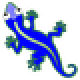

In [10]:
target_label = 'lizard_blue' #@param ["liz_no_tail", "liz_no_leg", "liz_no_head", "lizard_no_arm", "lizard_red", "lizard_blue"]

target_img = load_image_from_file(target_map[target_label])
imshow(zoom(to_rgb(target_img), 2), fmt='png')

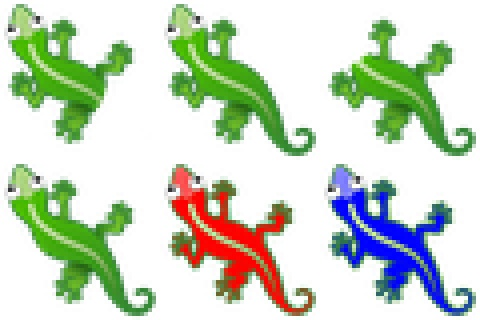

In [11]:
# compose picture of all perturbations
perts_fp_list = [lizard_no_tail_fp, lizard_no_leg_fp, lizard_no_head_fp, lizard_no_arm_fp, lizard_red_fp, lizard_blue_fp]
perts_img_list = [to_rgb(load_image_from_file(pfp)) for pfp in perts_fp_list]

imshow(zoom(tile2d(perts_img_list), 4))

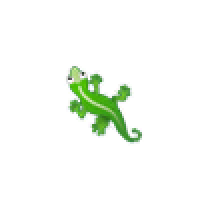

In [12]:
#@title Initialize Training { vertical-output: true}
TARGET_PADDING = 32 # From the previous section

p = TARGET_PADDING
pad_target = tf.pad(target_img, [(p, p), (p, p), (0, 0)])
h, w = pad_target.shape[:2]
seed = np.zeros([h, w, CHANNEL_N], np.float32)
seed[h//2, w//2, 3:] = 1.0

def loss_f(x):
  return tf.reduce_mean(tf.square(to_rgba(x)-pad_target), [-2, -3, -1])

target_emoji = '🦎' # '🦋'
ca = get_model(emoji=target_emoji)

# Generate the final state to modify.
x0_seed = seed[None, ...]
for gen in tf.range(200):
  x0_seed = ca(x0_seed)
imshow(zoom(to_rgb(x0_seed[0]), 2), fmt='png')

loss_log = []


loss0 = loss_f(seed).numpy()

initial_pool_elems = np.concatenate([
    np.repeat(seed[None, ...], POOL_SIZE // 2, 0),
    np.repeat(x0_seed, POOL_SIZE // 2, 0)], 0)
pool = SamplePool(x=initial_pool_elems)


# New for CMA-ES

iu = np.triu_indices(16)         # row/col indices of upper triangle incl. diagonal; iu[0] and iu[1] are each length 136

init_vec = np.eye(16, dtype=np.float32)[iu]   # length 136, ones on positions where iu[0]==iu[1], zeros elsewhere. Starting vector for the ES

!mkdir -p train_log && rm -f train_log/*

batch (before/after):


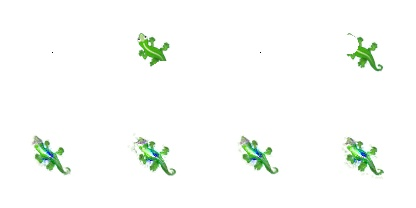

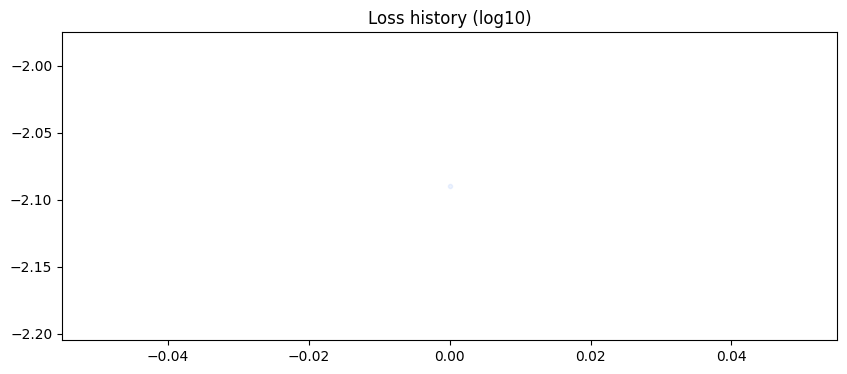

 step: 2, log10(loss): -2.149, log10(best): -2.149, sigma: 4.43e-03

In [13]:
!pip install cma
import cma
#@title Training Loop {vertical-output: true}

SEARCH_OPTUNA = False
N_GENERATIONS = 2
BATCH_SIZE = 4
sigma0 = 0.004789
es = cma.CMAEvolutionStrategy(init_vec, sigma0, {'popsize': 64})
POPSIZE = es.popsize
print("popsize:", POPSIZE)

# Precomputed indicator tensor for batched vec(136) -> symmetric 16x16.
# indicator[i,j,k] = 1 iff entry k of the 136-vec maps to position (i,j).
# Off-diagonal entries are mirrored, diagonal entries are written twice with the
# same value, exactly matching vec_to_sym() above.
_iu = np.triu_indices(16)
_indicator = np.zeros((16, 16, 136), dtype=np.float32)
for _k in range(136):
    _r, _c = _iu[0][_k], _iu[1][_k]
    _indicator[_r, _c, _k] = 1.0
    _indicator[_c, _r, _k] = 1.0
indicator_tf = tf.constant(_indicator)

@tf.function(jit_compile=True)
def evaluate_batch(x_init, V, iter_n):
    # x_init: [B, H, W, C]   shared starting state, broadcast to every candidate
    # V:      [P, 136]       all CMA-ES candidate vectors stacked
    # iter_n: scalar int32   number of NCA steps (variable per generation)
    # returns: x_final [P, B, H, W, C], losses_per_candidate [P]
    # P comes from V's static shape, so changing popsize triggers a clean retrace
    # rather than a shape-mismatch crash from a stale Python closure.
    P = V.shape[0]
    B, H, W, C = x_init.shape
    M = tf.einsum('pk,ijk->pij', V, indicator_tf)              # [P, 16, 16]
    x = tf.tile(x_init[None], [P, 1, 1, 1, 1])                  # [P, B, H, W, C]
    for _ in tf.range(iter_n):
        x_flat = tf.reshape(x, [P * B, H, W, C])
        lm = tf.cast(get_living_mask(x_flat), tf.float32)       # [P*B, H, W, 1]
        lm = tf.reshape(lm, [P, B, H, W, 1])
        x = tf.einsum('pbhwc,pcd->pbhwd', x, M)                 # per-candidate mutation
        x = tf.clip_by_value(x, -3., 3.)
        x = x * lm
        x_flat = tf.reshape(x, [P * B, H, W, C])
        x_flat = ca(x_flat)                                     # one fused NCA pass over all candidates
        x = tf.reshape(x_flat, [P, B, H, W, C])
    x_flat = tf.reshape(x, [P * B, H, W, C])
    losses = tf.reshape(loss_f(x_flat), [P, B])
    return x, tf.reduce_mean(losses, axis=1)


for gen in range(N_GENERATIONS):
  iter_n = np.random.randint(64, 96)
  batch = pool.sample(BATCH_SIZE)
  x0 = batch.x
  loss_rank = loss_f(x0).numpy().argsort()[::-1]
  x0 = x0[loss_rank]
  x0[:1] = seed
  x0[1:2] = x0_seed[0]
  if DAMAGE_N:
    damage = 1.0-make_circle_masks(DAMAGE_N, h, w).numpy()[..., None]
    x0[-DAMAGE_N:] *= damage

  candidates = es.ask()                                          # list of POPSIZE arrays of shape (136,)
  V = tf.constant(np.stack(candidates).astype(np.float32))       # [P, 136]
  x_init_t = tf.constant(x0)
  xs_out, fitnesses_t = evaluate_batch(
      x_init_t, V, tf.constant(iter_n, dtype=tf.int32))
  fitnesses = fitnesses_t.numpy().tolist()
  es.tell(candidates, fitnesses)
  elite_idx = int(np.argmin(fitnesses))
  elite_x = xs_out[elite_idx]                                    # tf tensor [B, H, W, C]

  batch.x[:] = elite_x.numpy()
  batch.commit()

  step_i = len(loss_log)
  loss_log.append(min(fitnesses))

  if step_i%10 == 0:
    generate_pool_figures(pool, step_i)
  if step_i%10 == 0:
    clear_output()
    visualize_batch(x0, elite_x, step_i)
    plot_loss(loss_log)
    export_model(ca, 'train_log/%04d'%step_i)

  print(f"\r step: {len(loss_log)}, log10(loss): {np.log10(min(fitnesses)):.3f}, "
      f"log10(best): {np.log10(min(loss_log)):.3f}, sigma: {es.sigma:.2e}", end='')

# Optuna Hyperparameter Search for CMA-ES

Tunes sigma0, batch_size, popsize, sigma decay factor, and decay frequency.

In [14]:
if SEARCH_OPTUNA == True:
    !pip install -q optuna
    import optuna
    import time
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    # Max safe parallel states: 64*8=512 is the original config.
    # Beyond this we OOM on current GPU. Constraint prunes those trials instantly.
    MAX_PARALLEL_STATES = 512

    def cma_objective(trial):
        sigma0_t       = trial.suggest_float("sigma0", 0.0002, 0.005, log=True)
        batch_size_t   = trial.suggest_categorical("batch_size", [4, 8])
        popsize_t      = trial.suggest_categorical("popsize",    [32, 64])
        decay_factor_t = trial.suggest_categorical("decay_factor", [0.9, 0.95, 0.975, 1.0])
        decay_freq_t   = trial.suggest_categorical(  "decay_freq", [100, 175, 250])

        # Prune immediately if this config would OOM before spending GPU time on it
        if popsize_t * batch_size_t > MAX_PARALLEL_STATES:
            raise optuna.TrialPruned()

        TIME_BUDGET   = 20 * 60  # 1200 seconds
        SMOOTH_WINDOW = 20

        trial_pool_elems = np.concatenate([
            np.repeat(seed[None, ...], POOL_SIZE // 2, 0),
            np.repeat(x0_seed,         POOL_SIZE // 2, 0)], 0)
        trial_pool = SamplePool(x=trial_pool_elems)

        _iu_t      = np.triu_indices(16)
        init_vec_t = np.eye(16, dtype=np.float32)[_iu_t]
        es = cma.CMAEvolutionStrategy(
            init_vec_t, sigma0_t, {'popsize': popsize_t, 'verbose': -9})

        total_evals   = 0
        gen           = 0
        recent_losses = []
        start         = time.time()

        while time.time() - start < TIME_BUDGET:
            iter_n    = np.random.randint(64, 96)
            batch     = trial_pool.sample(batch_size_t)
            x0        = batch.x
            loss_rank = loss_f(x0).numpy().argsort()[::-1]
            x0        = x0[loss_rank]
            x0[:1]    = seed
            x0[1:2]   = x0_seed[0]
            if DAMAGE_N:
                damage         = 1.0 - make_circle_masks(DAMAGE_N, h, w).numpy()[..., None]
                x0[-DAMAGE_N:] *= damage

            candidates = es.ask()
            V          = tf.constant(np.stack(candidates).astype(np.float32))
            x_init_t   = tf.constant(x0)
            try:
                xs_out, fitnesses_t = evaluate_batch(
                    x_init_t, V, tf.constant(iter_n, dtype=tf.int32))
            except tf.errors.ResourceExhaustedError:
                # Unexpected OOM (e.g. memory fragmentation) - prune gracefully
                raise optuna.TrialPruned()

            fitnesses = fitnesses_t.numpy().tolist()
            es.tell(candidates, fitnesses)

            elite_idx  = int(np.argmin(fitnesses))
            batch.x[:] = xs_out[elite_idx].numpy()
            batch.commit()

            if gen > 0 and gen % decay_freq_t == 0:
                es.sigma *= decay_factor_t

            total_evals   += popsize_t
            gen           += 1
            recent_losses.append(min(fitnesses))

            if gen % 10 == 0:
                intermediate = float(np.mean(recent_losses[-10:]))
                trial.report(intermediate, int(time.time() - start))
                if trial.should_prune():
                    raise optuna.TrialPruned()

        return float(np.mean(recent_losses[-SMOOTH_WINDOW:]))

In [15]:
if SEARCH_OPTUNA == True:
    #@title Run Optuna study { vertical-output: true }
    sampler = optuna.samplers.TPESampler(seed=42)
    pruner  = optuna.pruners.MedianPruner(n_startup_trials=1, n_warmup_steps=300)

    study = optuna.create_study(
        direction="minimize",
        sampler=sampler,
        pruner=pruner,
        study_name="cma_state_perturbation")

    def print_trial(study, trial):
        if trial.state == optuna.trial.TrialState.COMPLETE:
            print(f"Trial {trial.number:2d}  loss={trial.value:.6f}  {trial.params}")
        elif trial.state == optuna.trial.TrialState.PRUNED:
            print(f"Trial {trial.number:2d}  PRUNED  {trial.params}")
    study.enqueue_trial({'sigma0': 0.004789, 'batch_size': 4, 'popsize': 64, 'decay_factor': 0.9, 'decay_freq': 175})
    study.optimize(cma_objective, n_trials=20, callbacks=[print_trial])

    print("\n=== Best trial ===")
    print(f"  loss={study.best_value:.6f}  {study.best_params}")


In [16]:
if SEARCH_OPTUNA == True:
    #@title Optuna results & visualizations
    import optuna.visualization as ov
    from IPython.display import display

    # Summary table sorted by objective value
    completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    pruned    = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
    print(f"Completed: {len(completed)}  |  Pruned: {len(pruned)}")

    rows = sorted([(t.value, t.params) for t in completed])
    for rank, (val, params) in enumerate(rows[:10], 1):
        print(f"\n#{rank}  loss={val:.6f}")
        for k, v in params.items():
            print(f"   {k}: {v}")

    # Visualizations (interactive HTML in Colab/JupyterLab)
    display(ov.plot_optimization_history(study))
    display(ov.plot_param_importances(study))
    display(ov.plot_parallel_coordinate(study))
    display(ov.plot_contour(study))

# Head-to-head: Evolved (CMA-ES) vs Backprop

The two ways of learning the **16x16 channel-mutation matrix** that adversarially
reprograms the *frozen* Growing-NCA are now compared under an identical, fixed
**wall-clock budget** (`TRAIN_SECONDS`):

1. **Evolved** - CMA-ES using the best hyper-parameters found by the Optuna sweep
   above (`study.best_params`).
2. **Backprop** - the original gradient-descent optimiser (Adam) on the mutation
   tensor.

Both optimise the *same* objective (`loss_f`), drive the *same* frozen NCA
(`ca`), start from the *same* seed/pool, and are rendered identically. We then
compare loss-vs-time, loss-vs-iteration, loss-vs-NCA-compute, final losses, and
the grown images. The XLA/trace compile of each method is warmed up *before* the
timer starts so it is not charged to the budget.


In [17]:
#@title Head-to-head: shared setup & helpers
import time

TRAIN_SECONDS = 30 * 60      # wall-clock budget per method (lower this for a quick test)
RENDER_STEPS  = 120          # NCA steps used when growing an image for display
EVAL_STEPS    = 96           # NCA steps used for the "grown-image loss" metric
EVAL_RUNS     = 4            # stochastic renders averaged for that metric
_iu16 = np.triu_indices(16)

def vec_to_sym(vec):
    """136-vector (upper triangle) -> symmetric 16x16, matching evaluate_batch."""
    M = np.zeros((16, 16), np.float32)
    M[_iu16] = np.asarray(vec, np.float32)
    return M + M.T - np.diag(np.diag(M))

def var_to_sym(var):
    """tf 16x16 Variable -> symmetric matrix, matching the backprop train step."""
    m_upper = tf.linalg.band_part(var, 0, -1)
    return (m_upper + tf.transpose(m_upper)
            - tf.linalg.tensor_diag(tf.linalg.diag_part(var))).numpy()

def fresh_pool():
    elems = np.concatenate([
        np.repeat(seed[None, ...], POOL_SIZE // 2, 0),
        np.repeat(x0_seed,         POOL_SIZE // 2, 0)], 0)
    return SamplePool(x=elems)

def render_growth(M, x_start, steps, capture=()):
    """Grow from x_start applying mutation M each NCA step. Returns (final, frames).

    Uses the exact same per-step recipe as training: living-mask, channel
    mutation, clip to +/-3, re-mask, then one frozen-NCA pass."""
    M_t = tf.constant(np.asarray(M, np.float32))
    x = tf.constant(np.asarray(x_start, np.float32)[None])
    cap = set(capture)
    frames = []
    for i in range(steps + 1):
        if i in cap:
            frames.append((i, to_rgb(x[0]).numpy()))
        lm = tf.cast(get_living_mask(x), tf.float32)
        x = tf.einsum('bhwc,cd->bhwd', x, M_t)
        x = tf.clip_by_value(x, -3., 3.) * lm
        x = ca(x)
    return x, frames

def grown_image_loss(M, steps=EVAL_STEPS, runs=EVAL_RUNS):
    """Mean +/- std loss of the image grown from the empty seed (NCA is stochastic)."""
    vals = [float(loss_f(render_growth(M, seed, steps)[0])[0]) for _ in range(runs)]
    return float(np.mean(vals)), float(np.std(vals))


In [18]:
#@title Train 30 min - Evolved (CMA-ES, best Optuna config) {vertical-output: true}

if SEARCH_OPTUNA == True:
    cfg = study.best_params
    sigma0_e    = cfg["sigma0"]
    popsize_e   = cfg["popsize"]
    batch_e     = cfg["batch_size"]
    decayf_e    = cfg["decay_factor"]
    decayfreq_e = cfg["decay_freq"]
    print("Evolved (best Optuna) config:", cfg)
elif SEARCH_OPTUNA == False:
    sigma0_e = 0.004789
    popsize_e   = 64
    batch_e     = 4
    decayf_e    = 0.9
    decayfreq_e = 175

es_e = cma.CMAEvolutionStrategy(
    np.eye(16, dtype=np.float32)[_iu16], sigma0_e,
    {'popsize': popsize_e, 'verbose': -9})
evo_pool = fresh_pool()

# Warm up the XLA compile for this (popsize, batch) so it is not charged to the budget.
evaluate_batch(tf.constant(evo_pool.sample(batch_e).x),
               tf.constant(np.zeros((popsize_e, 136), np.float32)),
               tf.constant(80, tf.int32))

evo_loss_log, evo_time_log, evo_steps_log = [], [], []
best_evo_loss, best_evo_vec = np.inf, None

def evo_generation():
    global best_evo_loss, best_evo_vec
    iter_n  = np.random.randint(64, 96)
    batch   = evo_pool.sample(batch_e)
    x0      = batch.x
    x0      = x0[loss_f(x0).numpy().argsort()[::-1]]
    x0[:1]  = seed
    x0[1:2] = x0_seed[0]
    if DAMAGE_N:
        dmg            = 1.0 - make_circle_masks(DAMAGE_N, h, w).numpy()[..., None]
        x0[-DAMAGE_N:] *= dmg
    cands = es_e.ask()
    V     = tf.constant(np.stack(cands).astype(np.float32))
    xs, fit_t = evaluate_batch(tf.constant(x0), V, tf.constant(iter_n, tf.int32))
    fit   = fit_t.numpy().tolist()
    es_e.tell(cands, fit)
    elite = int(np.argmin(fit))
    batch.x[:] = xs[elite].numpy(); batch.commit()
    if min(fit) < best_evo_loss:
        best_evo_loss = min(fit); best_evo_vec = np.array(cands[elite], np.float32)
    return min(fit), popsize_e * batch_e * iter_n   # exact NCA state-steps this gen

gen, cum = 0, 0
start = time.time()
while time.time() - start < TRAIN_SECONDS:
    g_loss, g_steps = evo_generation()
    cum += g_steps
    if gen > 0 and gen % decayfreq_e == 0:
        es_e.sigma *= decayf_e
    evo_loss_log.append(g_loss)
    evo_time_log.append(time.time() - start)
    evo_steps_log.append(cum)
    gen += 1
    print(f"\r[evo] gen {gen:4d}  t={evo_time_log[-1]:5.0f}s  "
          f"log10(loss)={np.log10(g_loss):.3f}  best={np.log10(best_evo_loss):.3f}  "
          f"sigma={es_e.sigma:.2e}", end='')

M_evo = vec_to_sym(best_evo_vec)
print(f"\nEvolved done: {gen} generations, best log10(loss)={np.log10(best_evo_loss):.3f}")


[evo] gen  366  t= 1803s  log10(loss)=-2.312  best=-2.399  sigma=1.18e-03
Evolved done: 366 generations, best log10(loss)=-2.399


In [19]:
#@title Train 30 min - Backprop (Adam on the mutation tensor) {vertical-output: true}
bp_batch   = 8
bp_lr      = 2e-3
bp_mut     = tf.Variable(tf.eye(CHANNEL_N))
bp_sched   = tf.keras.optimizers.schedules.PiecewiseConstantDecay([2000], [bp_lr, bp_lr * 0.1])
bp_trainer = tf.keras.optimizers.Adam(bp_sched)
bp_pool    = fresh_pool()

@tf.function
def bp_train_step(x, iter_n):
    with tf.GradientTape() as g:
        m_upper = tf.linalg.band_part(bp_mut, 0, -1)
        M = m_upper + tf.transpose(m_upper) - tf.linalg.tensor_diag(tf.linalg.diag_part(bp_mut))
        for _ in tf.range(iter_n):
            lm = tf.cast(get_living_mask(x), tf.float32)
            x  = tf.einsum('bhwc,cd->bhwd', x, M)
            x  = tf.clip_by_value(x, -3., 3.) * lm
            x  = ca(x)
        loss = tf.reduce_mean(loss_f(x))
    grads = g.gradient(loss, [bp_mut])
    grads = [gr / (tf.norm(gr) + 1e-8) for gr in grads]
    bp_trainer.apply_gradients(zip(grads, [bp_mut]))
    return x, loss

def bp_step():
    iter_n  = np.random.randint(64, 96)
    batch   = bp_pool.sample(bp_batch)
    x0      = batch.x
    x0      = x0[loss_f(x0).numpy().argsort()[::-1]]
    x0[:1]  = seed
    x0[1:2] = x0_seed[0]
    if DAMAGE_N:
        dmg            = 1.0 - make_circle_masks(DAMAGE_N, h, w).numpy()[..., None]
        x0[-DAMAGE_N:] *= dmg
    x, loss = bp_train_step(tf.constant(x0), tf.constant(iter_n, tf.int32))
    batch.x[:] = x.numpy(); batch.commit()
    return float(loss), bp_batch * iter_n   # exact NCA state-steps this step

# Warm up the trace, then reset so the warm-up step is not part of the timed run.
bp_step()
bp_mut.assign(tf.eye(CHANNEL_N))
bp_pool = fresh_pool()

bp_loss_log, bp_time_log, bp_steps_log = [], [], []
best_bp_loss = np.inf
step, cum = 0, 0
start = time.time()
while time.time() - start < TRAIN_SECONDS:
    l, s = bp_step()
    cum += s
    best_bp_loss = min(best_bp_loss, l)
    bp_loss_log.append(l); bp_time_log.append(time.time() - start); bp_steps_log.append(cum)
    step += 1
    print(f"\r[bp]  step {step:4d}  t={bp_time_log[-1]:5.0f}s  "
          f"log10(loss)={np.log10(l):.3f}  best={np.log10(best_bp_loss):.3f}", end='')

M_bp = var_to_sym(bp_mut)
print(f"\nBackprop done: {step} steps, best log10(loss)={np.log10(best_bp_loss):.3f}")


[bp]  step 4719  t= 1800s  log10(loss)=-2.317  best=-2.510
Backprop done: 4719 steps, best log10(loss)=-2.510


metric                                 Evolved        Backprop
--------------------------------------------------------------
iterations                                 366            4719
wall-clock (s)                            1803            1800
best training loss                    0.003993        0.003089
final-iter loss                       0.004875        0.004823
grown-image loss                      0.004511        0.003562
grown-image loss std                  0.000297        0.000217
NCA state-steps                      7.472e+06       2.994e+06
sec to reach 0.0040                     1181.3            16.9
--------------------------------------------------------------
baseline loss0 (empty seed)           0.021845


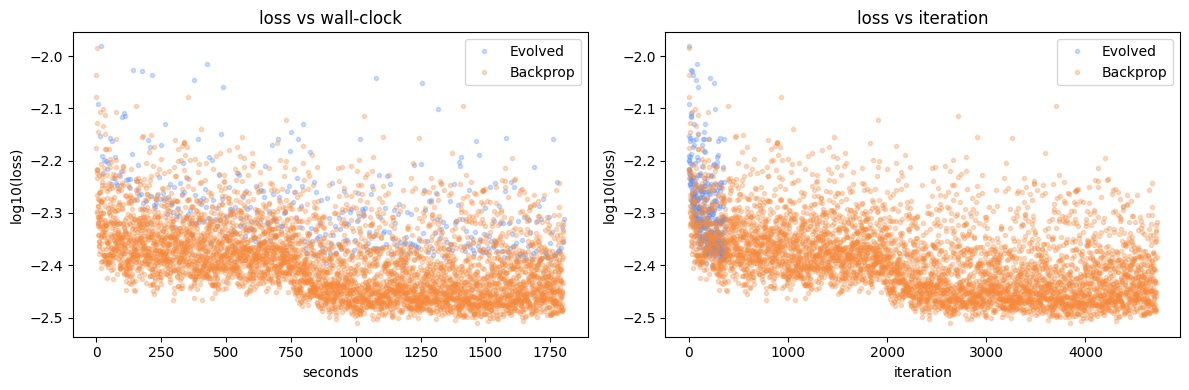

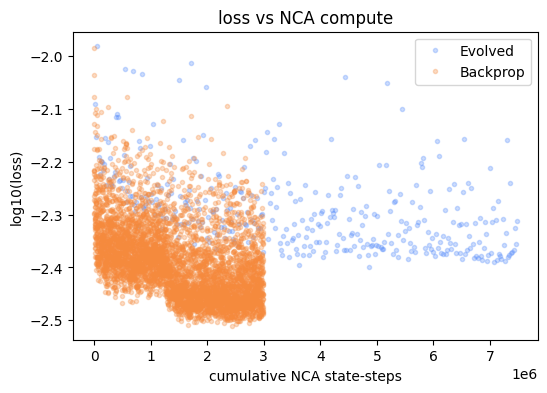

Target  |  Evolved  |  Backprop   (grown from the empty seed)


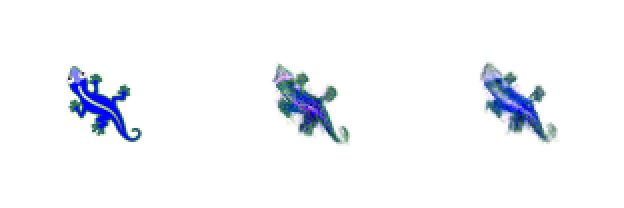

Evolved growth (steps [0, 20, 40, 60, 80, 100, 120]):


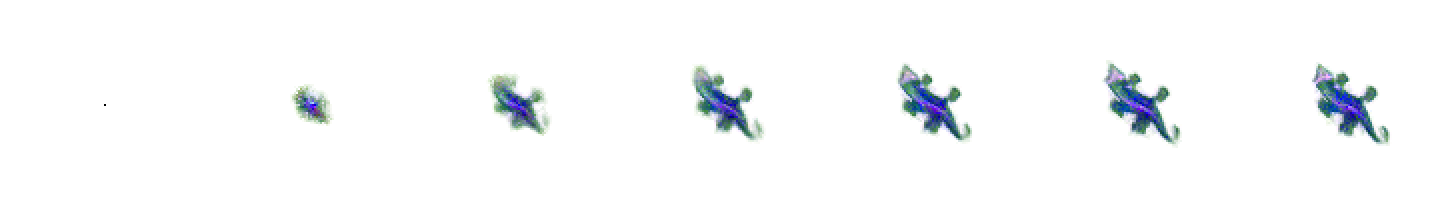

Backprop growth (steps [0, 20, 40, 60, 80, 100, 120]):


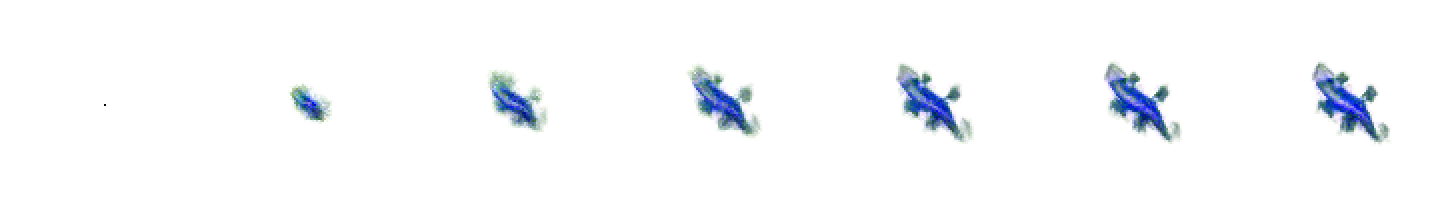

Healthy  |  Evolved morph  |  Backprop morph   (mutation applied to a grown lizard)


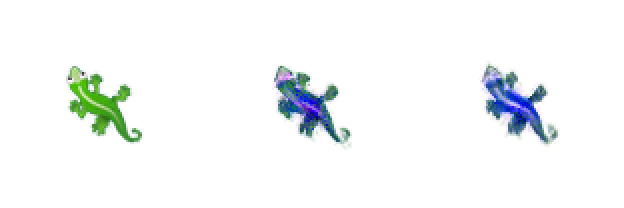

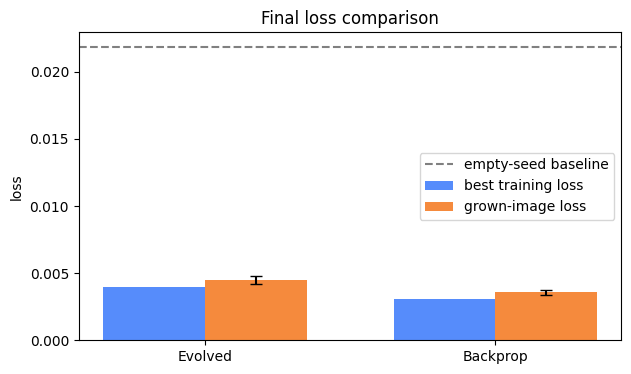

In [20]:
#@title Compare: Evolved vs Backprop {vertical-output: true}

# ---- final-quality metric: loss of the image actually grown from the seed ----
ev_grown, ev_grown_sd = grown_image_loss(M_evo)
bp_grown, bp_grown_sd = grown_image_loss(M_bp)

def time_to(loss_log, time_log, thr):
    for l, t in zip(loss_log, time_log):
        if l <= thr:
            return t
    return float('nan')

thr   = max(best_evo_loss, best_bp_loss)   # quality level both methods reached
t_evo = time_to(evo_loss_log, evo_time_log, thr)
t_bp  = time_to(bp_loss_log,  bp_time_log,  thr)

def row(label, a, b, fmt="{:>16.6f}"):
    print(f"{label:30s}" + fmt.format(a) + fmt.format(b))

print("=" * 62)
print(f"{'metric':30s}{'Evolved':>16s}{'Backprop':>16s}")
print("-" * 62)
row("iterations",            len(evo_loss_log), len(bp_loss_log), "{:>16d}")
row("wall-clock (s)",        evo_time_log[-1],  bp_time_log[-1],  "{:>16.0f}")
row("best training loss",    best_evo_loss,     best_bp_loss)
row("final-iter loss",       evo_loss_log[-1],  bp_loss_log[-1])
row("grown-image loss",      ev_grown,          bp_grown)
row("grown-image loss std",  ev_grown_sd,       bp_grown_sd)
row("NCA state-steps",       evo_steps_log[-1], bp_steps_log[-1], "{:>16.3e}")
row(f"sec to reach {thr:.4f}", t_evo,           t_bp,             "{:>16.1f}")
print("-" * 62)
print(f"{'baseline loss0 (empty seed)':30s}{loss0:>16.6f}")
print("=" * 62)

# ---- loss curves ----
pl.figure(figsize=(12, 4))
pl.subplot(1, 2, 1)
pl.title('loss vs wall-clock'); pl.xlabel('seconds'); pl.ylabel('log10(loss)')
pl.plot(evo_time_log, np.log10(evo_loss_log), '.', alpha=.3, label='Evolved')
pl.plot(bp_time_log,  np.log10(bp_loss_log),  '.', alpha=.3, label='Backprop')
pl.legend()
pl.subplot(1, 2, 2)
pl.title('loss vs iteration'); pl.xlabel('iteration'); pl.ylabel('log10(loss)')
pl.plot(np.log10(evo_loss_log), '.', alpha=.3, label='Evolved')
pl.plot(np.log10(bp_loss_log),  '.', alpha=.3, label='Backprop')
pl.legend(); pl.tight_layout(); pl.show()

pl.figure(figsize=(6, 4))
pl.title('loss vs NCA compute'); pl.xlabel('cumulative NCA state-steps'); pl.ylabel('log10(loss)')
pl.plot(evo_steps_log, np.log10(evo_loss_log), '.', alpha=.3, label='Evolved')
pl.plot(bp_steps_log,  np.log10(bp_loss_log),  '.', alpha=.3, label='Backprop')
pl.legend(); pl.show()

# ---- grown images: target | evolved | backprop ----
CAP = [0, 20, 40, 60, 80, 100, RENDER_STEPS]
evo_final, evo_frames = render_growth(M_evo, seed, RENDER_STEPS, CAP)
bp_final,  bp_frames  = render_growth(M_bp,  seed, RENDER_STEPS, CAP)

trio = np.hstack([to_rgb(pad_target).numpy(),
                  to_rgb(evo_final[0]).numpy(),
                  to_rgb(bp_final[0]).numpy()])
print('Target  |  Evolved  |  Backprop   (grown from the empty seed)')
imshow(zoom(trio, 2), fmt='png')

print('Evolved growth (steps %s):' % CAP)
imshow(zoom(np.hstack([f for _, f in evo_frames]), 2), fmt='png')
print('Backprop growth (steps %s):' % CAP)
imshow(zoom(np.hstack([f for _, f in bp_frames]), 2), fmt='png')

# ---- apply the learned mutation to an already-grown (healthy) lizard ----
evo_morph, _ = render_growth(M_evo, x0_seed[0], RENDER_STEPS)
bp_morph,  _ = render_growth(M_bp,  x0_seed[0], RENDER_STEPS)
morph = np.hstack([to_rgb(x0_seed[0]).numpy(),
                   to_rgb(evo_morph[0]).numpy(),
                   to_rgb(bp_morph[0]).numpy()])
print('Healthy  |  Evolved morph  |  Backprop morph   (mutation applied to a grown lizard)')
imshow(zoom(morph, 2), fmt='png')

# ---- final-loss bar chart ----
pl.figure(figsize=(7, 4))
labels = ['Evolved', 'Backprop']
xpos   = np.arange(len(labels)); bw = 0.35
pl.bar(xpos - bw / 2, [best_evo_loss, best_bp_loss], bw, label='best training loss')
pl.bar(xpos + bw / 2, [ev_grown, bp_grown], bw, yerr=[ev_grown_sd, bp_grown_sd],
       capsize=4, label='grown-image loss')
pl.axhline(loss0, ls='--', c='gray', label='empty-seed baseline')
pl.xticks(xpos, labels); pl.ylabel('loss'); pl.title('Final loss comparison')
pl.legend(); pl.show()


In [1]:
#@title Final perturbation matrices: Gradient vs CMA-ES {vertical-output: true}
np.set_printoptions(precision=3, suppress=True, linewidth=200)

print("Gradient (backprop) final perturbation matrix  M_bp  (16x16):")
print(M_bp)
print(f"\n||M_bp - I||_F = {np.linalg.norm(M_bp - np.eye(16)):.4f}")

print("\n" + "=" * 70 + "\n")

print("CMA-ES (evolved) final perturbation matrix  M_evo  (16x16):")
print(M_evo)
print(f"\n||M_evo - I||_F = {np.linalg.norm(M_evo - np.eye(16)):.4f}")

In [ ]:
#@title Perturbation-matrix heatmaps: Gradient vs CMA-ES {vertical-output: true}
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white", context="paper")

# Shared, symmetric color scale so the two methods are directly comparable.
vmax = float(np.max(np.abs([M_bp, M_evo])))
vmin = -vmax

fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
for ax, M, title in zip(axes, [M_bp, M_evo],
                        ["Gradient (backprop)", "CMA-ES (evolved)"]):
    sns.heatmap(M, ax=ax, cmap="RdBu_r", vmin=vmin, vmax=vmax, center=0,
                square=True, cbar=False, linewidths=0.3, linecolor="white",
                xticklabels=range(16), yticklabels=range(16))
    ax.set_title(f"{title}\n$\\|M-I\\|_F$ = {np.linalg.norm(M - np.eye(16)):.3f}",
                 fontsize=11)
    ax.set_xlabel("input channel")
    ax.set_ylabel("output channel")
    ax.tick_params(labelsize=7)

# One shared colorbar for both panels.
cbar = fig.colorbar(axes[0].collections[0], ax=axes, fraction=0.046, pad=0.02,
                    location="right")
cbar.set_label("mutation weight", fontsize=10)

fig.suptitle("Final perturbation matrices", fontsize=13, fontweight="bold")
plt.savefig("perturbation_matrices_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()